In [46]:
import jax
import jax.numpy as jnp
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import numpyro
import numpyro.distributions as dist
from numpyro.distributions.constraints import real
import pandas as pd

import pollux as plx
from pollux.models.transforms import LinearTransform

from process_rvs import process_spectra

jax.config.update("jax_enable_x64", True)

from matplotlib import rcParams

params = {
   'axes.labelsize': 15,
   'font.size': 15,
   'legend.fontsize': 14,
   'xtick.minor.visible': True,
   'ytick.minor.visible': True,
   'xtick.labelsize': 15,
   'ytick.labelsize': 15,
   'text.usetex': True, #to use TeX in your labels
   'font.family':'serif',
   'axes.titlesize': 15,
   'xtick.direction': 'in',
   'ytick.direction': 'in',
   'xtick.top': True,
   'ytick.right': True,
   'xtick.major.size': 6,
   'xtick.minor.size': 3,
   'ytick.major.size': 6,
   'ytick.minor.size': 3
   }
rcParams.update(params)


In [47]:
df_stars = pd.read_pickle('../data/giants_rel_most_rel.pkl')
df_gaia_rvs = pd.read_pickle('../data/all_giants_rvs_fluxes.pkl')
df_gaia_rvs = df_gaia_rvs.head(500)

# First, train the model with df_stars

In [48]:
n_all_stars = len(df_stars)
n_stars = n_all_stars  # number of simulated stars to generate in the train and test sets
labels = ['teff', 'logg', 'fe_h', 'mg_h', 'n_h', 'si_h', 'ni_h', 'ca_h', 'ce_h']
n_labels = len(labels)  # number of labels to generate per star
#n_latents = n_labels * 4  # size of the latent vector per star
n_latents = 21
n_flux = 2401  # number of spectral flux pixels per star

rng = np.random.default_rng(seed=8675309)

A = np.zeros((n_labels, n_latents))
A[0, 0] = 1.0
A[1, 1] = 1.0

B = rng.normal(scale=0.1, size=(n_flux, n_latents))
B[:, 0] = B[:, 0] + 4 * np.exp(-0.5 * (np.arange(n_flux) - n_flux / 2) ** 2 / 5**2)
B[:, 1] = B[:, 1] + 2 * np.exp(-0.5 * (np.arange(n_flux) - n_flux / 4) ** 2 / 3**2)

In [49]:
print("Number of all stars = ", len(df_stars))
df_stars = df_stars[:n_stars]
print("Number of stars in our set = ", len(df_stars))
df_stars.head(1)

Number of all stars =  1667
Number of stars in our set =  1667


,source_id,flux,flux_error,teff,e_teff,logg,e_logg,n_h,e_n_h,mg_h,...,si_h,e_si_h,fe_h,e_fe_h,ni_h,e_ni_h,ca_h,e_ca_h,ce_h,e_ce_h
0,4664665578195665280,"[--, --, 0.9704861, 0.97988486, 0.97052944, 0....","[--, --, 0.01576104, 0.00933747, 0.006561436, ...",4707.933105,3.487,2.45,0.008,-0.151,0.002828,-0.064,...,-0.104,0.002236,-0.344,0.001,-0.185,0.001,-0.174,0.002236,-0.416,0.001


In [50]:
# List of error column names corresponding to labels
params_errors = [f"e_{p}" if not p.startswith('e_') else p for p in labels]

# Stack columns for labels
df_stars_labels = np.column_stack([df_stars[p] for p in labels])

# Stack columns for errors
df_stars_label_errs = np.column_stack([df_stars[e] for e in params_errors])

df_stars = df_stars.reset_index(drop=True)

df_stars_labels.shape

(1667, 9)

In [51]:
fluxes_with_ca_mask = []
flux_errs_with_ca_mask = []

lambdas = np.linspace(846, 870, 2401)

for i in range(len(df_stars['flux'])):
	flux_single,flux_err_single = process_spectra(lambdas,df_stars['flux'].iloc[i],df_stars['flux_error'].iloc[i])

	fluxes_with_ca_mask.append(flux_single)
	flux_errs_with_ca_mask.append(flux_err_single)

In [52]:
stars_dict = {
    'label': df_stars_labels,
    'label_err': df_stars_label_errs,
    'flux': fluxes_with_ca_mask,
    'flux_err': flux_errs_with_ca_mask
}

In [53]:
stars_dict['flux'] = np.vstack([f.filled(1) if isinstance(f, np.ma.MaskedArray) else f
                              for f in stars_dict['flux']])

# Convert flux_err list to 2D array
stars_dict['flux_err'] = np.vstack([f.filled(9999) if isinstance(f, np.ma.MaskedArray) else f
                                  for f in stars_dict['flux_err']])

In [54]:
all_data = plx.data.PolluxData(
    flux=plx.data.OutputData(
        stars_dict["flux"],
        err=stars_dict["flux_err"],
        preprocessor=plx.data.ShiftScalePreprocessor.from_data(stars_dict["flux"]),
    ),
    label=plx.data.OutputData(
        stars_dict["label"],
        err=stars_dict["label_err"],
        preprocessor=plx.data.ShiftScalePreprocessor.from_data(stars_dict["label"]),
    )
)

preprocessed_data = all_data.preprocess()

train_data = preprocessed_data[: n_stars // 2]
test_data = preprocessed_data[n_stars // 2 :]
len(train_data), len(test_data)

test_flux_only = plx.data.PolluxData(flux=test_data["flux"])

In [55]:
model = plx.LuxModel(latent_size=n_latents)

In [56]:
print(all_data.keys())  # noqa: T201
model.register_output("label", LinearTransform(output_size=n_labels))
model.register_output("flux", LinearTransform(output_size=n_flux))

dict_keys(['flux', 'label'])


In [57]:
opt_pars, svi_results = model.optimize(
    train_data,
    rng_key=jax.random.PRNGKey(112358),
    optimizer=numpyro.optim.Adam(1e-3),
    num_steps=10_000,
    svi_run_kwargs={"progress_bar": False},
)
svi_results.losses.block_until_ready()

Array([1.12215499e+08, 1.11497068e+08, 1.10786476e+08, ...,
       2.36622918e+06, 2.36622102e+06, 2.36621313e+06], dtype=float64)

In [58]:
predict_train_values = model.predict_outputs(opt_pars["latents"], opt_pars)

In [59]:
fixed_pars = {
    "label": {"data": {"A": opt_pars["label"]["data"]["A"]}},
    "flux": {"data": {"A": opt_pars["flux"]["data"]["A"]}},
}

In [60]:
flux_only_data = plx.data.PolluxData(flux=test_data["flux"])

test_opt_pars_flux, _ = model.optimize(
    flux_only_data,
    rng_key=jax.random.PRNGKey(12345),
    optimizer=numpyro.optim.Adam(1e-3),
    num_steps=10_000,
    fixed_pars=fixed_pars,
    names=["flux"],
    svi_run_kwargs={"progress_bar": False},
)

predict_test_values_flux = model.predict_outputs(
    test_opt_pars_flux["latents"], opt_pars
)

svi_results.losses.block_until_ready()

Array([1.12215499e+08, 1.11497068e+08, 1.10786476e+08, ...,
       2.36622918e+06, 2.36622102e+06, 2.36621313e+06], dtype=float64)

In [61]:
predict_test_unprocessed_flux = test_data.unprocess(predict_test_values_flux)
test_data_unprocessed = test_data.unprocess()

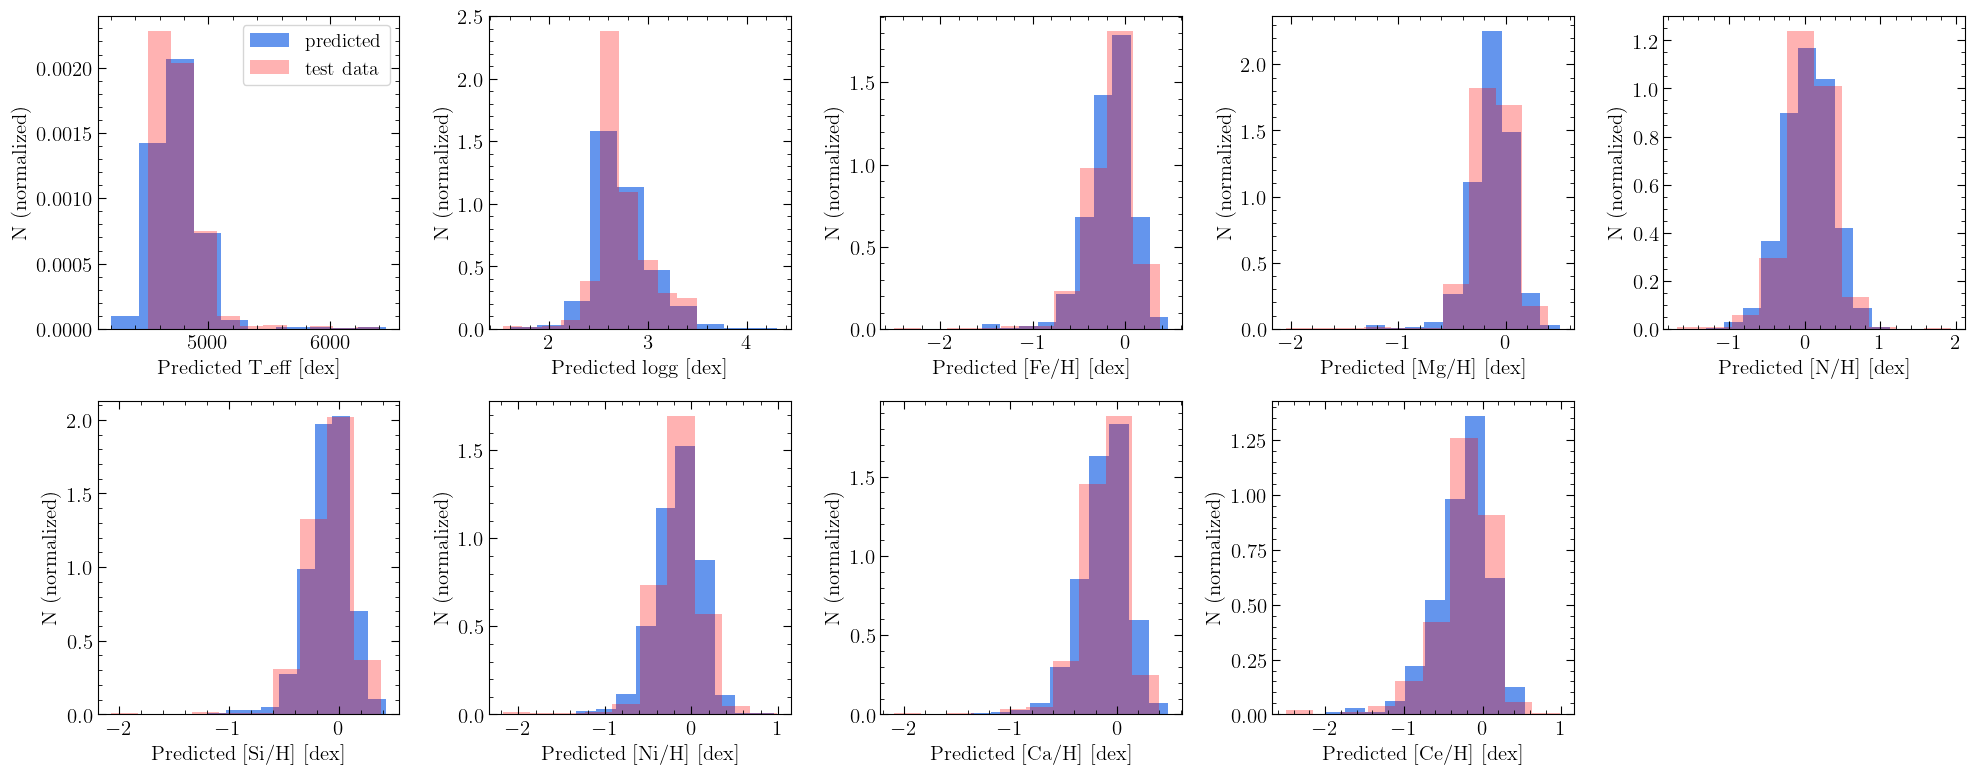

In [62]:
plt.figure(figsize=(20,8))
label_names = ['T_eff', 'logg', '[Fe/H]', '[Mg/H]', '[N/H]', '[Si/H]', '[Ni/H]', '[Ca/H]', '[Ce/H]']

# 1. Extract data into memory ONCE before the loop
pred_data = predict_test_unprocessed_flux["label"].data[:]
test_data = test_data_unprocessed["label"].data[:]

for i in range(1, 10):
    plt.subplot(2, 5, i)
    
    # 2. Slice from the in-memory arrays
    plt.hist(pred_data[:, i-1], density=True, color='cornflowerblue', label='predicted')
    plt.hist(test_data[:, i-1], density=True, color='red', label='test data', alpha=0.3)
    
    plt.xlabel(f"Predicted {label_names[i-1]} [dex]")
    plt.ylabel("N (normalized)")
    
    # 3. Call legend AFTER plotting the data
    if i == 1:
        plt.legend()

plt.tight_layout()

# Now use the model to precit values for all giants in RVS

In [24]:
# processing for all gaia rvs
all_fluxes_with_ca_mask = []
all_flux_errs_with_ca_mask = []


for i in range(len(df_gaia_rvs['flux'])):
	all_flux_single,all_flux_err_single = process_spectra(lambdas,df_gaia_rvs['flux'].iloc[i],df_gaia_rvs['flux_error'].iloc[i])

	all_fluxes_with_ca_mask.append(all_flux_single)
	all_flux_errs_with_ca_mask.append(all_flux_err_single)

In [25]:
all_flux_dict = {
    'flux': all_fluxes_with_ca_mask,
    'flux_err': all_flux_errs_with_ca_mask
}

In [26]:
all_flux_dict['flux'] = np.vstack([f.filled(1) if isinstance(f, np.ma.MaskedArray) else f
                              for f in all_flux_dict['flux']])

# Convert flux_err list to 2D array
all_flux_dict['flux_err'] = np.vstack([f.filled(9999) if isinstance(f, np.ma.MaskedArray) else f
                                  for f in all_flux_dict['flux_err']])

In [27]:
all_flux_data = plx.data.PolluxData(
    flux=plx.data.OutputData(
        all_flux_dict["flux"],
        err=all_flux_dict["flux_err"],
        preprocessor=plx.data.ShiftScalePreprocessor.from_data(stars_dict["flux"]),
    )
)

preprocessed_all_flux_data = all_flux_data.preprocess()

In [28]:
flux_only_data = plx.data.PolluxData(flux=all_flux_data["flux"])

test_opt_pars_flux, _ = model.optimize(
    flux_only_data,
    rng_key=jax.random.PRNGKey(12345),
    optimizer=numpyro.optim.Adam(1e-3),
    num_steps=10_000,
    fixed_pars=fixed_pars,
    names=["flux"],
    svi_run_kwargs={"progress_bar": False},
)

predict_test_values_flux = model.predict_outputs(
    test_opt_pars_flux["latents"], opt_pars
)
predict_test_unprocessed_flux = test_data.unprocess(predict_test_values_flux)

In [29]:
len(predict_test_unprocessed_flux["label"].data[:,0])

500

(array([  2.,   3.,   6.,  27.,  83., 148., 157.,  65.,   7.,   2.]),
 array([4776.6595323 , 4791.2049485 , 4805.75036469, 4820.29578088,
        4834.84119707, 4849.38661326, 4863.93202945, 4878.47744564,
        4893.02286183, 4907.56827802, 4922.11369421]),
 <BarContainer object of 10 artists>)

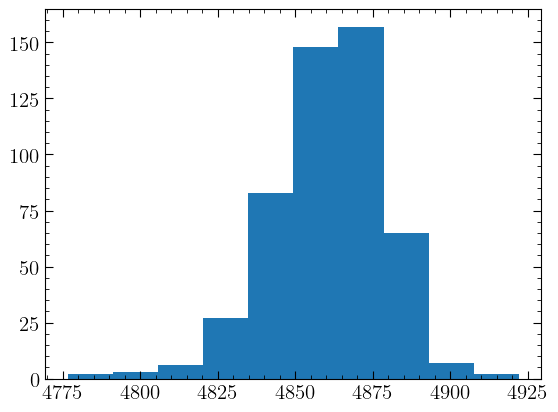

In [30]:
plt.hist(predict_test_unprocessed_flux["label"].data[:,0])

In [ ]:
plt.figure(figsize=(20,8))
label_names = ['T_eff', 'logg', '[Fe/H]', '[Mg/H]', '[N/H]', '[Si/H]', '[Ni/H]', '[Ca/H]', '[Ce/H]']

for i in range(1,10):
    plt.subplot(2, 5, i)
    if i == 1:
        plt.legend()
    plt.hist(predict_test_unprocessed_flux["label"].data[:, i-1], density=True, color = 'cornflowerblue', label = 'predicted')
    plt.hist(test_unprocess["label"].data[:, i-1], density=True, color = 'red', label = 'test data', alpha = 0.3)
    plt.xlabel(f"Predicted {label_names[i-1]} [dex]")
    plt.ylabel("N (normalized)")

plt.tight_layout()

/var/folders/g0/fl404sj151l2v9xcdkjz9fq80000gn/T/ipykernel_83799/1654049862.py:7: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


In [ ]:
mg_h = pred_iter_unprocess["label"].data[3]
fe_h = pred_iter_unprocess["label"].data[2]
fe_mg = fe_h - mg_h

In [ ]:
len(mg_h)

9

In [ ]:
len(fe_h)

9

In [ ]:
mg_h

Array([ 4.71936362e+03,  2.73201020e+00, -2.29881298e-01, -2.00991332e-01,
       -2.77227620e-01, -1.64227146e-01, -4.69913395e-01, -3.26215781e-01,
       -7.92616440e-01], dtype=float64)

(-1.0, 1.0)

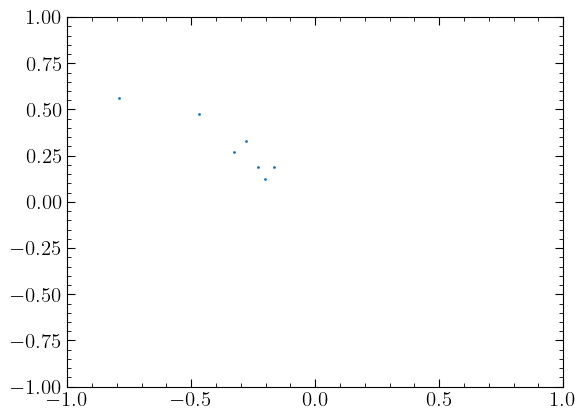

In [ ]:
plt.scatter(mg_h, fe_mg, s = 1)
plt.ylim(-1,1)
plt.xlim(-1,1)